# Optimizer Comparison: H2

This notebook compares all optimizers registered in `vqe.optimizer.OPTIMIZERS`
for **VQE** on the hydrogen molecule **H2**, using each optimizer's calibrated default stepsize from the package registry.

Goals:

- keep the molecule and ansatz fixed
- run VQE with each registered optimizer at its default stepsize
- compare convergence behaviour and final energies

This isolates the effect of the classical optimization step.

In [25]:
from __future__ import annotations

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

from vqe.core import run_vqe
from vqe.optimizer import OPTIMIZERS
from common.hamiltonian import get_exact_spectrum

## Setup

We fix:

- molecule: `H2`
- ansatz: `UCCSD`
- step count
- random seed

Only the optimizer changes.

In [ ]:
molecule = "H2"
ansatz_name = "UCCSD"
steps = 75
seed = 0

# Preserve the registry order defined in vqe.optimizer.
optimizer_names = list(OPTIMIZERS.keys())

## Exact ground-state reference

For a small system like `H2`, we can compare final VQE energies against the
exact ground-state value.

In [27]:
exact_spectrum = np.asarray(get_exact_spectrum(molecule), dtype=float)
exact_spectrum = np.sort(exact_spectrum)
exact_ground_energy = float(exact_spectrum[0])

exact_ground_energy

-1.1372701748841751

## Run VQE for each optimizer

In [28]:
results = {}

for optimizer_name in optimizer_names:
    print(f"Running {optimizer_name} ...")
    res = run_vqe(
        molecule=molecule,
        ansatz_name=ansatz_name,
        optimizer_name=optimizer_name,
        steps=steps,
        seed=seed,
        noisy=False,
        force=False,
        plot=False,
    )
    results[optimizer_name] = res

Running Adam ...
Running GradientDescent ...
Running Momentum ...


Running NesterovMomentum ...
Running RMSProp ...
Running Adagrad ...


## Final energies

In [29]:
summary_rows = []

for optimizer_name, res in results.items():
    final_energy = float(res["energy"])
    abs_error = abs(final_energy - exact_ground_energy)
    n_steps = len(res["energies"])

    summary_rows.append(
        {
            "optimizer": optimizer_name,
            "final_energy": final_energy,
            "abs_error": abs_error,
            "steps": n_steps,
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values(["abs_error", "final_energy"])
display(summary_df.round(8))


,optimizer,final_energy,abs_error,steps
3,NesterovMomentum,-1.137270,1.200000e-07,76
2,Momentum,-1.137269,1.190000e-06,76
4,RMSProp,-1.137266,4.590000e-06,76
0,Adam,-1.137260,1.028000e-05,76
5,Adagrad,-1.133778,3.491910e-03,76
1,GradientDescent,-1.131023,6.246940e-03,76


In [30]:
best_row = summary_df.iloc[0]
print(
    f"Best optimizer: {best_row['optimizer']} | "
    f"final energy = {best_row['final_energy']:.10f} | "
    f"abs error = {best_row['abs_error']:.6e} | "
    f"steps = {int(best_row['steps'])}"
)


Best optimizer: NesterovMomentum | final energy = -1.1372700559 | abs error = 1.190109e-07 | steps = 76


## Convergence curves

Plot the energy trajectory for each optimizer on the same axes.

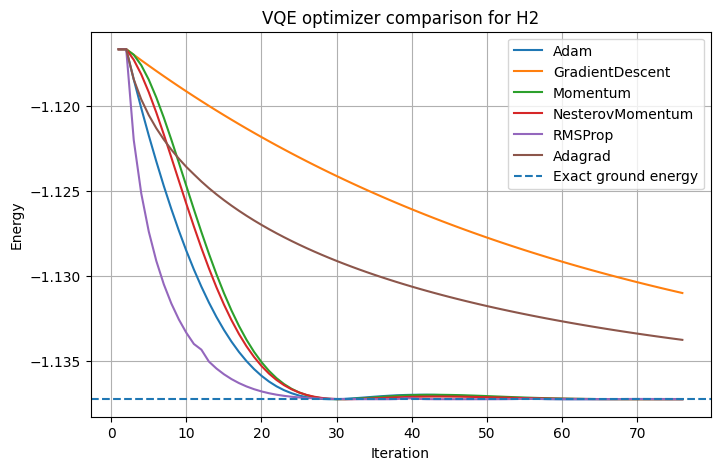

In [31]:
plt.figure(figsize=(8, 5))

for optimizer_name, res in results.items():
    energies = np.asarray(res["energies"], dtype=float)
    plt.plot(
        np.arange(1, len(energies) + 1),
        energies,
        label=optimizer_name,
    )

plt.axhline(exact_ground_energy, linestyle="--", label="Exact ground energy")
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.title("VQE optimizer comparison for H2")
plt.grid(True)
plt.legend()
plt.show()


## Final-energy comparison

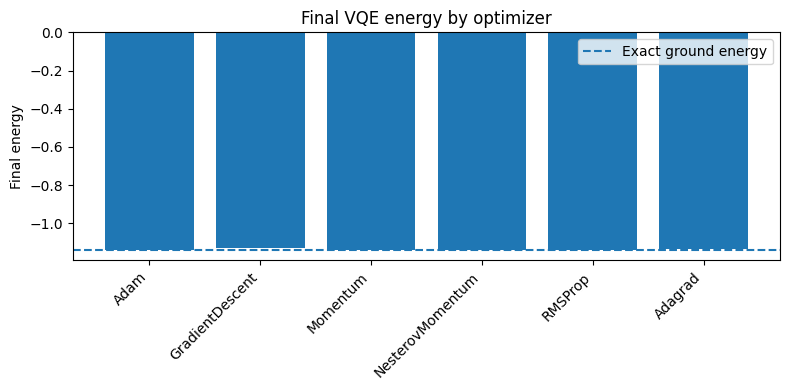

In [32]:
final_energies = [float(results[name]["energy"]) for name in optimizer_names]

plt.figure(figsize=(8, 4))
plt.bar(optimizer_names, final_energies)
plt.axhline(exact_ground_energy, linestyle="--", label="Exact ground energy")
plt.ylabel("Final energy")
plt.title("Final VQE energy by optimizer")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.legend()
plt.show()


## Interpretation

Things to look for:

- which optimizer converges fastest
- which optimizer reaches the lowest final energy
- which optimizer is most stable across iterations

In many small VQE examples, **Adam** is a strong default because it is usually
robust to step-size sensitivity. Here each optimizer is run with its calibrated package default.

Simpler optimizers can still be useful:

- **GradientDescent** as a baseline
- **NesterovMomentum** when the landscape is smooth
- **RMSProp / Adagrad** for adaptive scaling behaviour

## What this notebook showed

We:

- fixed the molecule and ansatz
- compared several classical optimizers
- plotted convergence curves
- compared final energies to the exact ground-state reference

This isolates the classical part of the VQE loop.